# Heston Model - Volatility Surface Analysis

This notebook demonstrates option pricing and volatility surface generation using the Heston stochastic volatility model with typical equity parameters.

In [34]:
import sys
sys.path.append('/Users/kevinlaventure/python_code')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
from python_module.pricing_model import HestonModel

## Heston Model Parameters

Typical equity parameters for the Heston model:
- **S**: Spot price (100)
- **r**: Risk-free rate (2%)
- **v0**: Initial variance (0.04 = 20% volatility)
- **kappa**: Mean reversion speed (2.0)
- **theta**: Long-term variance level (0.04 = 20% volatility)
- **sigma**: Volatility of volatility (0.3)
- **rho**: Correlation between spot and variance (-0.7, typical negative correlation)

In [35]:
# Typical equity Heston parameters
S = 100.0           # Spot price
r = 0.0            # Risk-free rate (2%)
v0 = 0.04           # Initial variance (20% volatility)
kappa = 20.0         # Mean reversion speed
theta = 0.04        # Long-term variance (20% volatility)
sigma = 0.0001        # Volatility of volatility
rho = 0          # Correlation (negative - leverage effect)

print("Heston Model Parameters:")
print(f"  Spot Price (S):           {S}")
print(f"  Risk-free Rate (r):       {r:.2%}")
print(f"  Initial Variance (v0):    {v0:.4f} (volatility: {np.sqrt(v0):.2%})")
print(f"  Mean Reversion (kappa):   {kappa}")
print(f"  Long-term Variance:       {theta:.4f} (volatility: {np.sqrt(theta):.2%})")
print(f"  Vol of Vol (sigma):       {sigma}")
print(f"  Correlation (rho):        {rho}")

Heston Model Parameters:
  Spot Price (S):           100.0
  Risk-free Rate (r):       0.00%
  Initial Variance (v0):    0.0400 (volatility: 20.00%)
  Mean Reversion (kappa):   20.0
  Long-term Variance:       0.0400 (volatility: 20.00%)
  Vol of Vol (sigma):       0.0001
  Correlation (rho):        0


## Volatility Surface Computation

We'll compute implied volatilities across different strikes and maturities to visualize the volatility smile/smirk effect generated by the Heston model.

In [36]:
from scipy.stats import norm

def compute_bs_implied_vol(S, K, T, r, market_price, option_type='call', tol=1e-6, max_iter=100):
    """Compute implied volatility from option price using Newton-Raphson"""
    # Better initial guess: use ATM volatility or moneyness-scaled guess
    moneyness = K / S
    sigma = np.sqrt(2 * np.abs(np.log(moneyness) / T)) if np.log(moneyness) != 0 else 0.2  # Default to 20% if ATM
    sigma = max(sigma, 0.01)  # Ensure minimum sigma to avoid division by zero
    
    for _ in range(max_iter):
        if sigma <= 0:
            sigma = 0.01  # Fallback to avoid division by zero
            
        d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        
        if option_type == 'call':
            price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
            vega = S * norm.pdf(d1) * np.sqrt(T)
        else:
            price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
            vega = S * norm.pdf(d1) * np.sqrt(T)
        
        if vega == 0 or vega < 1e-10:
            break
        
        sigma_new = sigma - (price - market_price) / vega
        sigma_new = max(sigma_new, 0.001)  # Ensure sigma stays positive
        
        if abs(sigma_new - sigma) < tol:
            return sigma_new
        sigma = sigma_new
    
    return sigma

# Define strike and maturity grids
strikes = np.linspace(S * 0.9, S * 1.1, 15)  # 70% to 130% moneyness
maturities = np.array([0.1, 0.25, 0.5, 1.0, 2.0])  # 1 month, 3 months, 6 months, 1 year, 2 years

# Compute volatility surface
vol_surface = np.zeros((len(maturities), len(strikes)))
price_surface = np.zeros((len(maturities), len(strikes)))

print(f"Computing volatility surface ({len(maturities)} maturities × {len(strikes)} strikes)...")

for i, T in enumerate(maturities):
    for j, K in enumerate(strikes):
        # Compute Heston price
        heston_price = HestonModel.compute_option_with_spot(
            S=S, K=K, T=T, r=r, v0=v0, 
            kappa=kappa, theta=theta, sigma=sigma, rho=rho,
            option_type='call', compute_greeks=False
        )
        price_surface[i, j] = heston_price
        
        # Compute implied volatility
        impl_vol = compute_bs_implied_vol(S, K, T, r, heston_price, option_type='call')
        vol_surface[i, j] = impl_vol
    
    print(f"  Maturity {T:.2f}Y: Complete")

print("Volatility surface computation complete!")

# Create a DataFrame for easier inspection
df_vol = pd.DataFrame(
    vol_surface,
    index=[f"{t:.2f}Y" for t in maturities],
    columns=[f"{k:.2f}" for k in strikes]
)
print("\nImplied Volatility Surface (Call Options):")
print(df_vol.round(4))

Computing volatility surface (5 maturities × 15 strikes)...
  Maturity 0.10Y: Complete
  Maturity 0.25Y: Complete
  Maturity 0.50Y: Complete
  Maturity 1.00Y: Complete
  Maturity 2.00Y: Complete
Volatility surface computation complete!

Implied Volatility Surface (Call Options):
        90.00   91.43   92.86   94.29   95.71   97.14   98.57  100.00  101.43  \
0.10Y  0.2178  0.2121  0.2084  0.2058  0.2045  0.2032  0.2026  0.2022  0.2018   
0.25Y  0.2070  0.2057  0.2049  0.2040  0.2032  0.2028  0.2025  0.2023  0.2020   
0.50Y  0.2050  0.2043  0.2036  0.2032  0.2029  0.2027  0.2025  0.2023  0.2021   
1.00Y  0.2037  0.2034  0.2032  0.2029  0.2028  0.2027  0.2025  0.2024  0.2022   
2.00Y  0.2033  0.2032  0.2030  0.2029  0.2028  0.2027  0.2026  0.2024  0.2023   

       102.86  104.29  105.71  107.14  108.57  110.00  
0.10Y  0.2017  0.2014  0.2012  0.2009  0.2008  0.2012  
0.25Y  0.2019  0.2018  0.2015  0.2014  0.2013  0.2012  
0.50Y  0.2019  0.2019  0.2018  0.2017  0.2015  0.2015  
1.00Y  0.

## 3D Volatility Surface Visualization

The 3D surface shows how implied volatility varies across strikes and maturities. The negative correlation (rho = -0.7) creates a volatility smile/smirk pattern typical of equity markets.

In [37]:
# Create 3D surface plot with Plotly
fig = go.Figure(data=[go.Surface(
    x=strikes,
    y=maturities,
    z=vol_surface,
    colorscale='Viridis',
    name='Implied Vol'
)])

fig.update_layout(
    title='Heston Model - Implied Volatility Surface',
    scene=dict(
        xaxis_title='Strike Price',
        yaxis_title='Time to Maturity (Years)',
        zaxis_title='Implied Volatility',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.3)
        )
    ),
    width=1000,
    height=700,
    showlegend=False
)

fig.show()

## 2D Volatility Surface - Cross-Sections

Volatility smile/smirk across different maturities. The skew (negative slope at OTM calls) is driven by the negative correlation parameter.


Maturity T=0.10Y:
  K/S=0.900 : IV=0.2178
  K/S=0.914 : IV=0.2121
  K/S=0.929 : IV=0.2084
  K/S=0.943 : IV=0.2058
  K/S=0.957 : IV=0.2045
  K/S=0.971 : IV=0.2032
  K/S=0.986 : IV=0.2026
  K/S=1.000 (ATM): IV=0.2022
  K/S=1.014 : IV=0.2018
  K/S=1.029 : IV=0.2017
  K/S=1.043 : IV=0.2014
  K/S=1.057 : IV=0.2012
  K/S=1.071 : IV=0.2009
  K/S=1.086 : IV=0.2008
  K/S=1.100 : IV=0.2012

Maturity T=0.25Y:
  K/S=0.900 : IV=0.2070
  K/S=0.914 : IV=0.2057
  K/S=0.929 : IV=0.2049
  K/S=0.943 : IV=0.2040
  K/S=0.957 : IV=0.2032
  K/S=0.971 : IV=0.2028
  K/S=0.986 : IV=0.2025
  K/S=1.000 (ATM): IV=0.2023
  K/S=1.014 : IV=0.2020
  K/S=1.029 : IV=0.2019
  K/S=1.043 : IV=0.2018
  K/S=1.057 : IV=0.2015
  K/S=1.071 : IV=0.2014
  K/S=1.086 : IV=0.2013
  K/S=1.100 : IV=0.2012

Maturity T=0.50Y:
  K/S=0.900 : IV=0.2050
  K/S=0.914 : IV=0.2043
  K/S=0.929 : IV=0.2036
  K/S=0.943 : IV=0.2032
  K/S=0.957 : IV=0.2029
  K/S=0.971 : IV=0.2027
  K/S=0.986 : IV=0.2025
  K/S=1.000 (ATM): IV=0.2023
  K/S=1.014 : IV

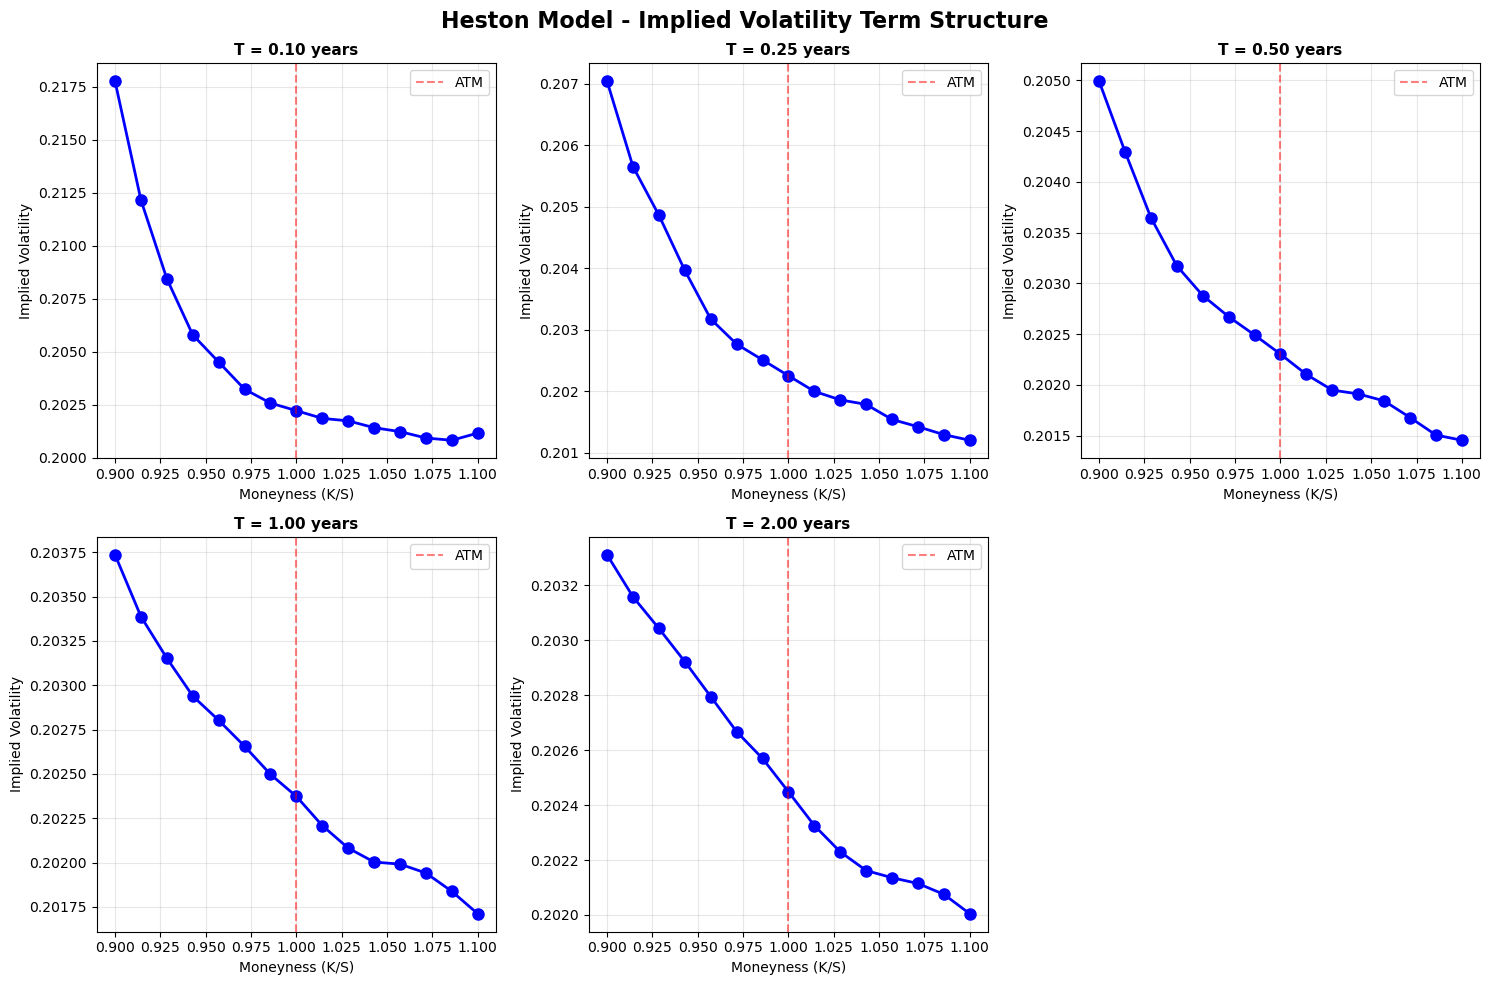

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Heston Model - Implied Volatility Term Structure', fontsize=16, fontweight='bold')

# Plot IV across strikes for different maturities
for idx, mat_idx in enumerate([0, 1, 2, 3, 4]):
    ax = axes[idx // 3, idx % 3]
    T = maturities[mat_idx]
    ax.plot(strikes / S, vol_surface[mat_idx, :], 'b-o', linewidth=2, markersize=8)
    ax.axvline(x=1.0, color='r', linestyle='--', alpha=0.5, label='ATM')
    ax.set_xlabel('Moneyness (K/S)', fontsize=10)
    ax.set_ylabel('Implied Volatility', fontsize=10)
    ax.set_title(f'T = {T:.2f} years', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Display IV values
    print(f"\nMaturity T={T:.2f}Y:")
    for k_idx, k in enumerate(strikes):
        moneyness = k / S
        iv = vol_surface[mat_idx, k_idx]
        is_atm = "(ATM)" if abs(moneyness - 1.0) < 0.01 else ""
        print(f"  K/S={moneyness:.3f} {is_atm}: IV={iv:.4f}")

# Remove the extra subplot
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

## Heatmap View - Implied Volatility Surface

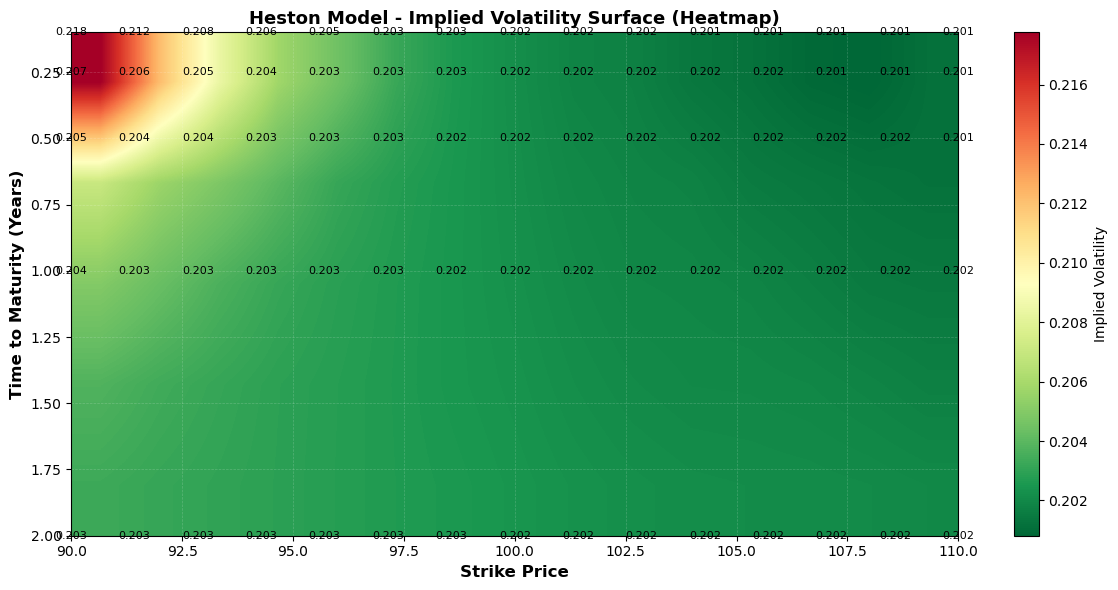

In [39]:
fig, ax = plt.subplots(figsize=(12, 6))

# Create heatmap
im = ax.imshow(vol_surface, aspect='auto', cmap='RdYlGn_r', 
               extent=[strikes[0], strikes[-1], maturities[-1], maturities[0]],
               origin='upper', interpolation='bilinear')

# Labels and title
ax.set_xlabel('Strike Price', fontsize=12, fontweight='bold')
ax.set_ylabel('Time to Maturity (Years)', fontsize=12, fontweight='bold')
ax.set_title('Heston Model - Implied Volatility Surface (Heatmap)', fontsize=13, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax, label='Implied Volatility')

# Add grid
ax.grid(True, alpha=0.2, color='white', linestyle='--', linewidth=0.5)

# Add text annotations
for i in range(len(maturities)):
    for j in range(len(strikes)):
        text = ax.text(strikes[j], maturities[i], f'{vol_surface[i, j]:.3f}',
                      ha="center", va="center", color="black", fontsize=8)

plt.tight_layout()
plt.show()

## Volatility Surface Analysis

Key observations from the Heston model volatility surface with typical equity parameters:

In [40]:
# Analysis of the volatility surface
print("=" * 80)
print("HESTON MODEL VOLATILITY SURFACE ANALYSIS")
print("=" * 80)

print(f"\nModel Parameters:")
print(f"  Initial Volatility (sqrt(v0)):     {np.sqrt(v0):.2%}")
print(f"  Long-term Volatility (sqrt(theta)): {np.sqrt(theta):.2%}")
print(f"  Mean Reversion Speed (kappa):       {kappa}")
print(f"  Vol of Vol (sigma):                 {sigma}")
print(f"  Correlation (rho):                  {rho}")

print(f"\nVolatility Smile/Skew Characteristics:")
print(f"  ATM Volatility (T=1Y):              {vol_surface[3, 7]:.4f}")

# Compute skew for 1Y maturity
out_of_money_idx = len(strikes) - 1
in_the_money_idx = 0
atm_idx = len(strikes) // 2

skew_1y = vol_surface[3, out_of_money_idx] - vol_surface[3, in_the_money_idx]
print(f"  Skew (OTM Call - ITM Call, 1Y):    {skew_1y:.4f}")

print(f"\nTerm Structure (ATM Volatilities):")
for i, T in enumerate(maturities):
    atm_iv = vol_surface[i, len(strikes) // 2]
    print(f"  T={T:.2f}Y: {atm_iv:.4f} ({atm_iv:.2%})")

print(f"\nMoneyness Effects at T=1Y:")
for j, K in enumerate(strikes):
    moneyness = K / S
    iv = vol_surface[3, j]
    price = price_surface[3, j]
    print(f"  K/S={moneyness:.3f}: IV={iv:.4f} ({iv:.2%}), Price={price:.4f}")

print("\n" + "=" * 80)
print("Key Insights:")
print("=" * 80)
print(f"1. Negative skew: The volatility decreases with increasing strike (OTM calls)")
print(f"   This is typical for equity markets due to the leverage effect (ρ={rho})")
print(f"\n2. Volatility term structure: Shown in the 2D plots")
print(f"   - Mean reversion creates term structure shape")
print(f"   - Longer maturities converge toward long-term volatility ({np.sqrt(theta):.2%})")
print(f"\n3. The Heston model naturally generates volatility smiles/smirks")
print(f"   because volatility is stochastic and correlated with spot moves")
print("=" * 80)

HESTON MODEL VOLATILITY SURFACE ANALYSIS

Model Parameters:
  Initial Volatility (sqrt(v0)):     20.00%
  Long-term Volatility (sqrt(theta)): 20.00%
  Mean Reversion Speed (kappa):       20.0
  Vol of Vol (sigma):                 0.0001
  Correlation (rho):                  0

Volatility Smile/Skew Characteristics:
  ATM Volatility (T=1Y):              0.2024
  Skew (OTM Call - ITM Call, 1Y):    -0.0020

Term Structure (ATM Volatilities):
  T=0.10Y: 0.2022 (20.22%)
  T=0.25Y: 0.2023 (20.23%)
  T=0.50Y: 0.2023 (20.23%)
  T=1.00Y: 0.2024 (20.24%)
  T=2.00Y: 0.2024 (20.24%)

Moneyness Effects at T=1Y:
  K/S=0.900: IV=0.2037 (20.37%), Price=13.7119
  K/S=0.914: IV=0.2034 (20.34%), Price=12.7760
  K/S=0.929: IV=0.2032 (20.32%), Price=11.8845
  K/S=0.943: IV=0.2029 (20.29%), Price=11.0349
  K/S=0.957: IV=0.2028 (20.28%), Price=10.2296
  K/S=0.971: IV=0.2027 (20.27%), Price=9.4652
  K/S=0.986: IV=0.2025 (20.25%), Price=8.7415
  K/S=1.000: IV=0.2024 (20.24%), Price=8.0598
  K/S=1.014: IV=0.202